<a href="https://colab.research.google.com/github/Rishabh1991mtu/Deep_LearningAI_Courses/blob/main/Timeseries_Airplanepassengers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Good morning, everyone! 😊☀️

I hope you’re all doing great today! Welcome to the session on time series analysis 📊✨. We’ll be working on the Air Passenger dataset, exploring trends and patterns—it’s going to be super exciting!

Let’s wait for a few moments for others to join 🕒, and then we’ll get started. Get ready for an amazing session ahead! 🚀📈

#Problem Statement:

#Predict the monthly airline passenger numbers for the next 12 months using historical data from 1949 to 1960.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [14]:
df = pd.read_csv('.//sample_data//AirPassengers.csv')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [16]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [17]:
# prompt: Convert month column to datetime instead of object

import pandas as pd

# Convert 'Month' column to datetime
df['Month'] = pd.to_datetime(df['Month'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [18]:
# Set 'Month' column as the index
df = df.set_index('Month') #  To make it univariate time series .

<Axes: xlabel='Month'>

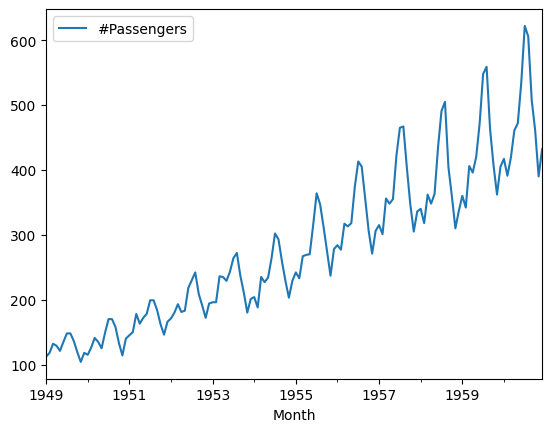

In [24]:
df.plot() # Plot data

1. The data has an increasing trend and seasonaility (There is a pattern for increasing/decreasing of passengers         
2. Trend is pattern -> Increasing or decreasing
3. Seasonality -> short term cycle in the data
4. residual(noise) -> sudden random change (stock price change ,death due to COVID)



In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

Figure(640x480)


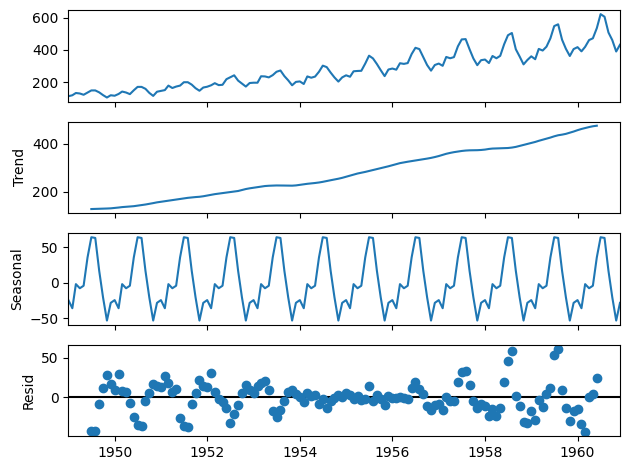

In [27]:
decomposed = seasonal_decompose(df)
print(decomposed.plot())

SARIMA model is used when seasonality is present.
ARIMA model .
Check data is stationary or not : Augmented Dicki fuller test . Do Hypothesis testing . Stationary -> constant mean and variance

Null Hypothesis -> Non Stationary .
Alternate Hypothsesis -> Stationary

In [28]:
from statsmodels.tsa.stattools import adfuller # augmented dickey fuller test

In [35]:
test_result = adfuller(df)
p_val = test_result[1]

In [36]:
if p_val < 0.05:
    print("The data is stationary")
else:
    print("The data is not stationary")

The data is not stationary


Stationary -> Constant mean and variance over time . window has to be taken into consideration

-> remove trend
-> seasonality

Apply logarithmic/power transformation : Stabilize the variance.

<Axes: xlabel='Month'>

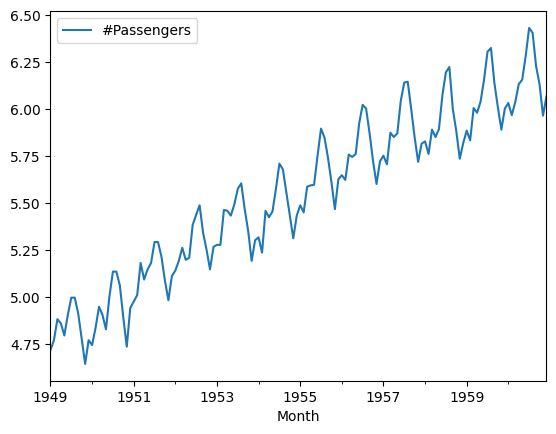

In [41]:
first_log = np.log(df)
first_log.dropna
first_log.plot()

In [42]:
first_log

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


Figure(640x480)


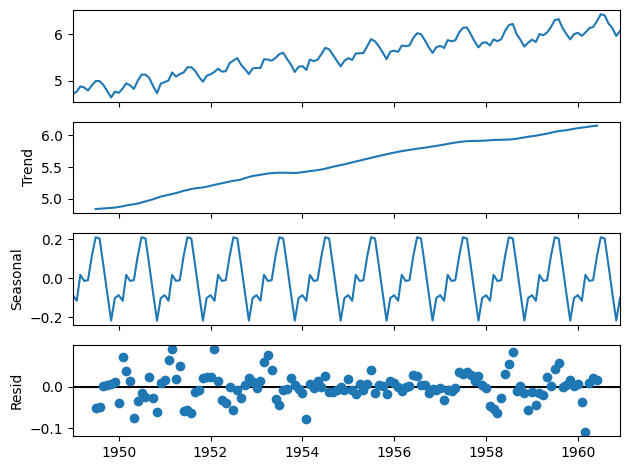

In [44]:
decomposed_first_log = seasonal_decompose(first_log)
print(decomposed_first_log.plot())

# Rolling mean (mean log)
This computes moving average of the time series over a specified window (in case -12) .
1. rolling mean :  It helps in smoothing out the short term fluctuations.
2. rolling standard deviation .

Month
1949-01-01         NaN
1949-02-01         NaN
1949-03-01         NaN
1949-04-01         NaN
1949-05-01         NaN
                ...   
1960-08-01    6.124517
1960-09-01    6.132246
1960-10-01    6.142628
1960-11-01    6.148837
1960-12-01    6.154215
Name: #Passengers, Length: 144, dtype: float64


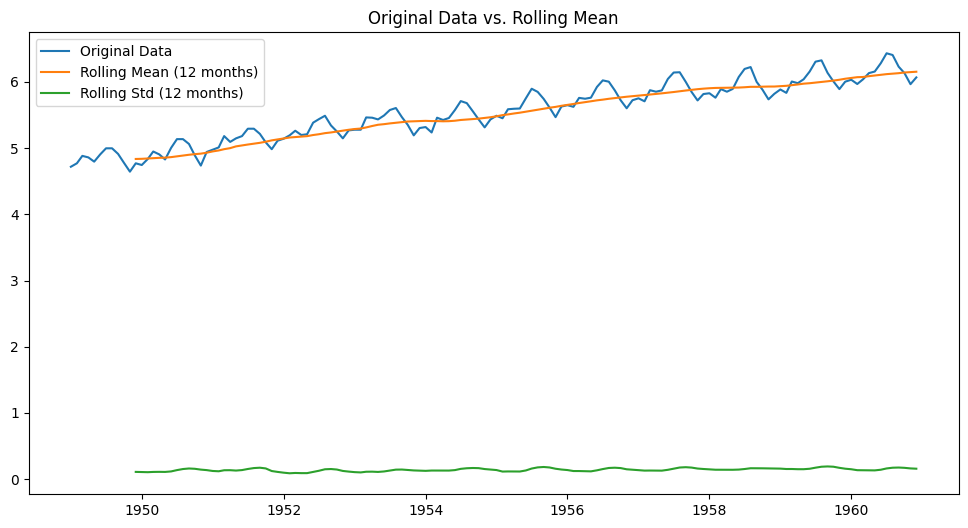

In [87]:
# prompt: How to calculate moving average for dataframe

# Calculate the rolling mean with a window of 12
rolling_mean = first_log['#Passengers'].rolling(window=12).mean()
rolling_std = first_log['#Passengers'].rolling(window=12).std()
# Print the rolling mean
print(rolling_mean)

# Plot the original data and the rolling mean
plt.figure(figsize=(12, 6))
plt.plot(first_log['#Passengers'], label='Original Data')
plt.plot(rolling_mean, label='Rolling Mean (12 months)')
plt.plot(rolling_std, label='Rolling Std (12 months)')
plt.legend()
plt.title('Original Data vs. Rolling Mean')
plt.show()

Mean is increasing , standard deviation is constant.

In [88]:
# prompt: new_data = first log - mean_log

# Calculate the difference between the first log and the rolling mean
new_data = first_log['#Passengers'] - rolling_mean
# Print or further process new_data as needed
new_data = new_data.dropna()
new_data

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [89]:
result = adfuller(new_data)
print(f"p_val {result[1]}")
p_val = result[1]
if p_val < 0.05:
    print("The data is stationary")
else:
    print("The data is not stationary")

p_val 0.022234630001242206
The data is stationary


Figure(640x480)


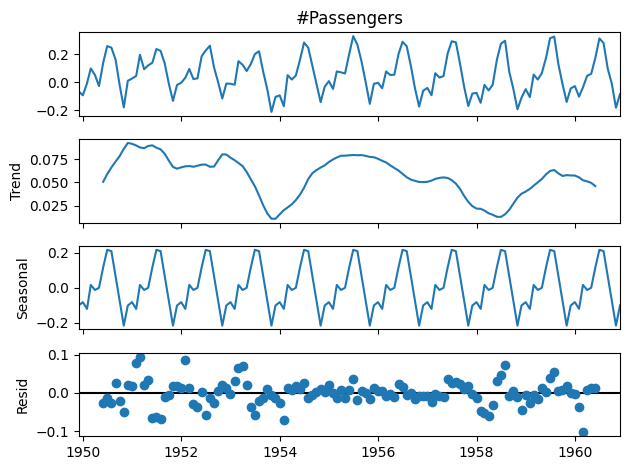

In [90]:
decomposed_transform = seasonal_decompose(new_data)
print(decomposed_transform.plot())

# Model building

In [91]:
train = new_data.iloc[:120]
test = new_data.iloc[120:]

In [92]:
train

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1959-07-01,0.316430
1959-08-01,0.327838
1959-09-01,0.128057


# ARIMA : Auto Regressive Integrated Moving Average Model

p , d , q parameters

p : order of lag <br> How many past values you want to use for prediction
d : degree of differencing <br>
q : order of moving average <br>

In [93]:
 from statsmodels.tsa.arima.model import ARIMA

In [94]:
A_model = ARIMA(train, order=(2,1,2))
A_model_fit = ARIMA(train, order=(4,1,5))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [95]:
A_model = A_model.fit()

In [96]:
new_data = pd.DataFrame(new_data)

In [97]:
new_data["Arima_predictions"] = A_model.predict(start=len(train), end=len(train) + len(test) - 1)
# start

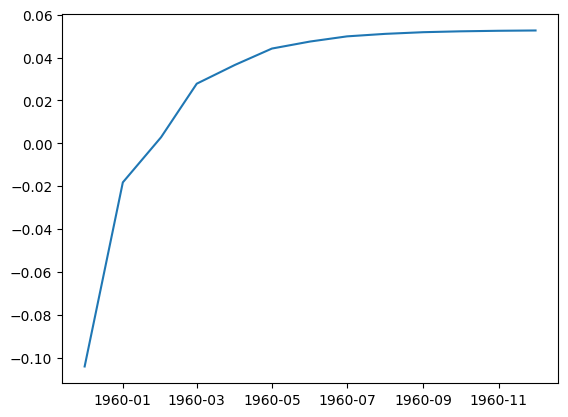

In [98]:
plt.plot(new_data["Arima_predictions"])

In [102]:
new_data.tail(10)

,#Passengers,Arima_predictions
Month,,
1960-03-01,-0.036530,0.027783
1960-04-01,0.046332,0.036547
1960-05-01,0.060186,0.044180
1960-06-01,0.175033,0.047461
1960-07-01,0.315151,0.049871
1960-08-01,0.282363,0.051039
1960-09-01,0.098235,0.051818
1960-10-01,-0.009230,0.052223
1960-11-01,-0.182690,0.052478


In [103]:
from sklearn.metrics import *


In [106]:
import itertools

p = range(0, 7)
d = range(1, 2)
q = range(0, 7)
pdq = list(itertools.product(p, d, q))
rmse_list = []
for param in pdq:
    try:
        model = ARIMA(train, order=param)
        model_fit = model.fit()
        predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1)
        rmse = np.sqrt(mean_squared_error(test, predictions))
        rmse_list.append((param, rmse))
    except:
        pass


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date